<a href="https://colab.research.google.com/github/sailadke19-cmd/crop-production-using-linear-regression/blob/main/crop_production_using_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
df=pd.read_csv("/content/Crop_production.csv")
df.head()

,Unnamed: 0,State_Name,Crop_Type,Crop,N,P,K,pH,rainfall,temperature,Area_in_hectares,Production_in_tons,Yield_ton_per_hec
0,0,andhra pradesh,kharif,cotton,120,40,20,5.46,654.34,29.266667,7300.0,9400.0,1.287671
1,1,andhra pradesh,kharif,horsegram,20,60,20,6.18,654.34,29.266667,3300.0,1000.0,0.303030
2,2,andhra pradesh,kharif,jowar,80,40,40,5.42,654.34,29.266667,10100.0,10200.0,1.009901
3,3,andhra pradesh,kharif,maize,80,40,20,5.62,654.34,29.266667,2800.0,4900.0,1.750000
4,4,andhra pradesh,kharif,moong,20,40,20,5.68,654.34,29.266667,1300.0,500.0,0.384615


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
State_Name,0
Crop_Type,0
Crop,0
N,0
P,0
K,0
pH,0
rainfall,0
temperature,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Unnamed: 0,N,P,K,pH,rainfall,temperature,Area_in_hectares,Production_in_tons,Yield_ton_per_hec
count,99849.000000,99849.000000,99849.000000,99849.000000,99849.000000,99849.000000,99849.000000,99849.000000,9.984900e+04,99849.000000
mean,49924.000000,69.816823,41.593656,42.037827,5.643624,701.151085,26.684154,16476.585668,3.776291e+04,3.931149
std,28824.067851,39.571469,15.056508,28.430263,0.505283,604.701552,4.851214,43604.268231,1.222447e+05,33.872242
min,0.000000,10.000000,10.000000,10.000000,3.820000,3.274569,1.180000,0.580000,0.000000e+00,0.000000
25%,24962.000000,50.000000,40.000000,20.000000,5.360000,157.310000,23.106000,130.000000,1.620000e+02,0.586207
50%,49924.000000,75.000000,40.000000,30.000000,5.540000,579.750000,27.333333,1010.000000,1.506000e+03,1.329268
75%,74886.000000,80.000000,60.000000,50.000000,5.960000,1110.780000,29.266667,8099.000000,1.439500e+04,2.997288
max,99848.000000,180.000000,125.000000,200.000000,7.000000,3322.060000,35.346667,726300.000000,3.530571e+06,9801.000000


In [ ]:
print('Row Index:', df.index)
print('Column Names:', df.columns)

Row Index: RangeIndex(start=0, stop=99849, step=1)
Column Names: Index(['Unnamed: 0', 'State_Name', 'Crop_Type', 'Crop', 'N', 'P', 'K', 'pH',
       'rainfall', 'temperature', 'Area_in_hectares', 'Production_in_tons',
       'Yield_ton_per_hec'],
      dtype='object')


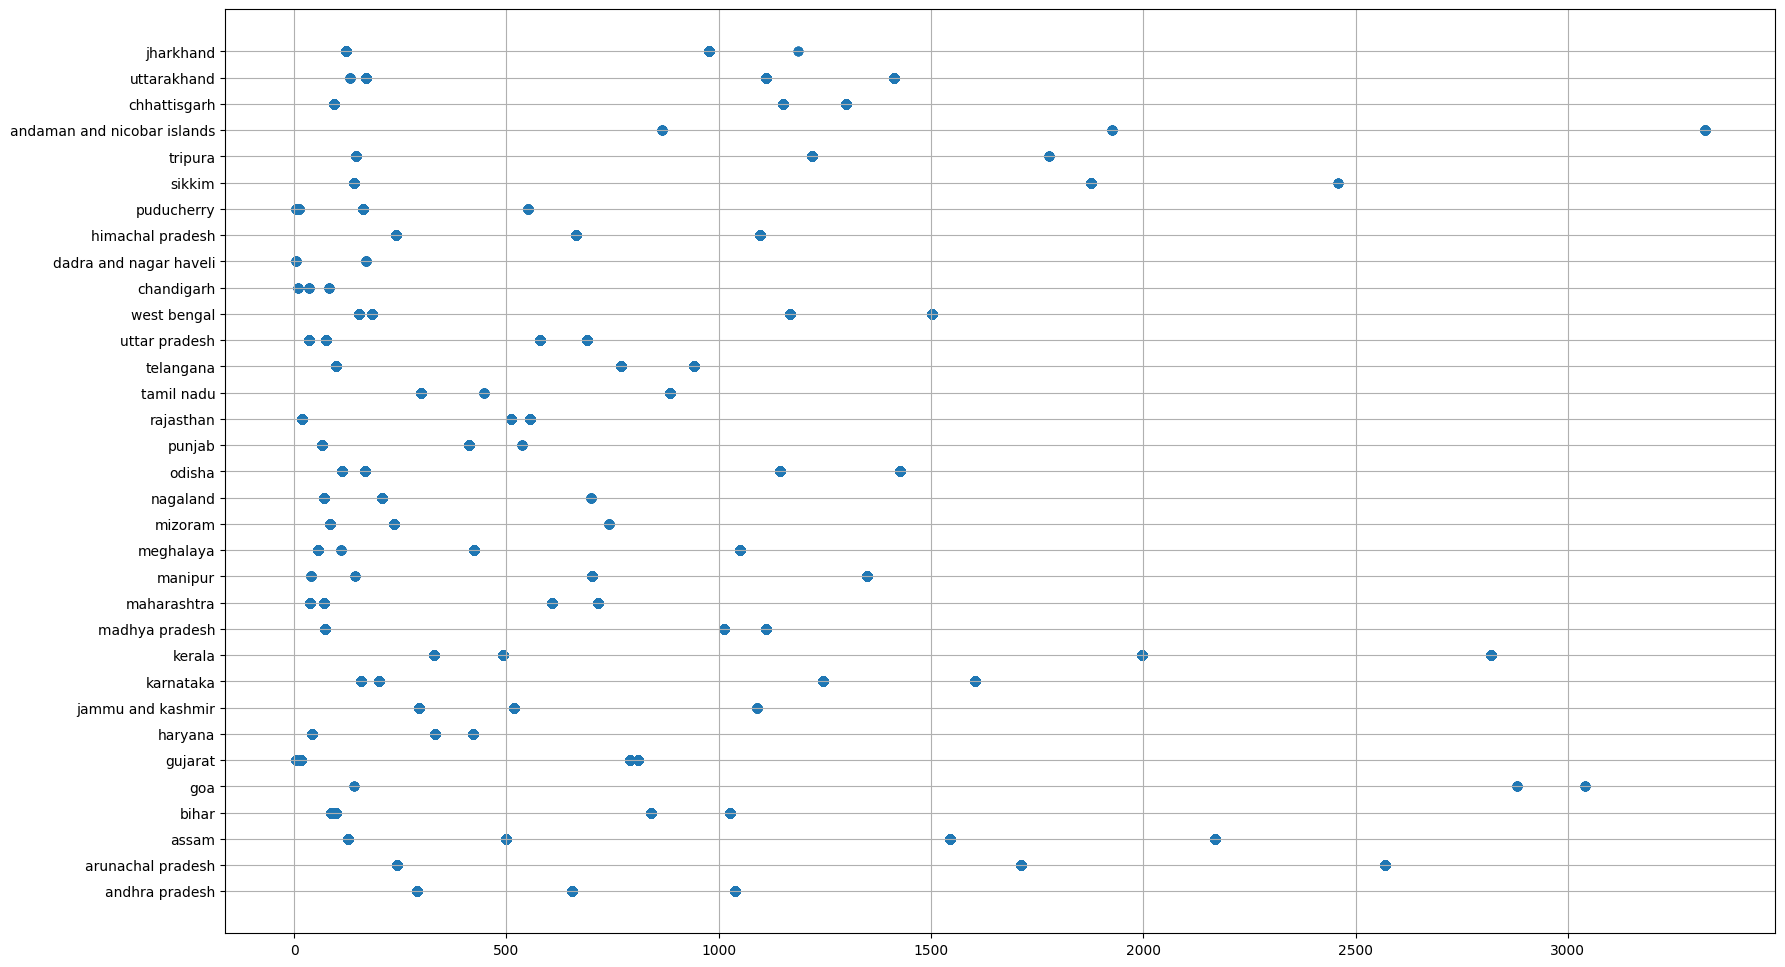

In [ ]:
x=df[['rainfall']]
y=df['State_Name']
plt.figure(figsize=(20,12))
plt.scatter(x, y)
plt.grid()
plt.show()

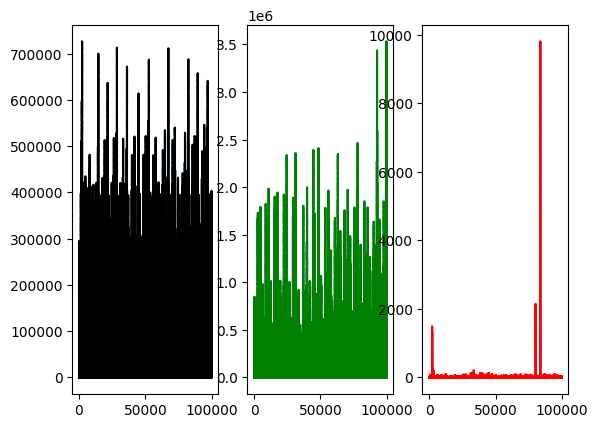

In [ ]:
x=df[['Area_in_hectares']]
y=df['Production_in_tons']
c=df['Yield_ton_per_hec']
plt.subplot(1,3,1)
plt.plot(x,linestyle='dashdot')
plt.plot(x, color = 'black')
plt.subplot(1,3,2)
plt.plot(y,linestyle='dashdot')
plt.plot(y, color = 'g')
plt.subplot(1,3,3)
plt.plot(c,linestyle='dashdot')
plt.plot(c, color = 'r')
plt.show()

In [ ]:
df.shape

(99849, 13)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=2529)

In [ ]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((79879, 1), (19970, 1), (79879,), (19970,))

In [ ]:
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
lr.score(x_test,y_test)*100

55.381529397714566

In [ ]:
area_input = float(input("Enter the Area in hectares:"))
predicted_production = lr.predict([[area_input]])
print(predicted_production)

Enter the Area in hectares:89
[4125.7892216]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


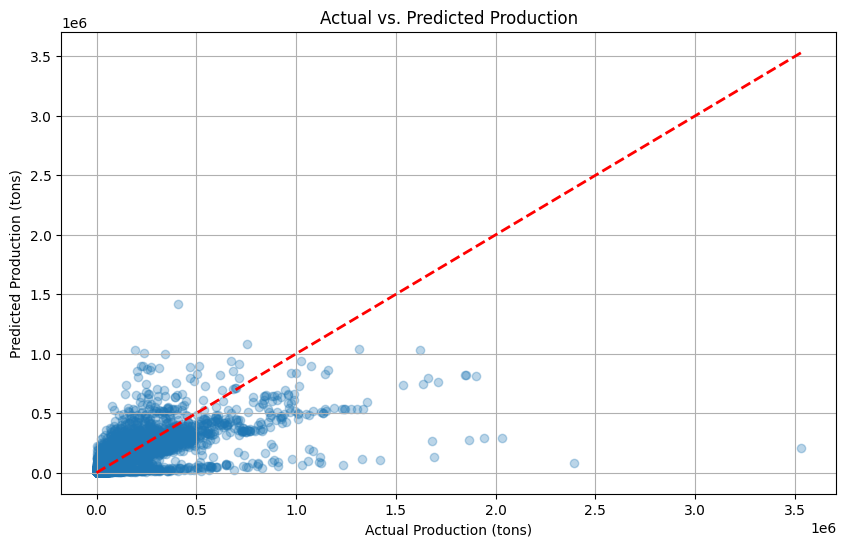

In [ ]:
y_pred = lr.predict(x_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Production (tons)")
plt.ylabel("Predicted Production (tons)")
plt.title("Actual vs. Predicted Production")
plt.grid(True)
plt.show()